# Volatility Surface Demo

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from options_pricing.models.black_scholes import BlackScholes

## Setup

Parameters:

- A fixed spot price $ S $
- A fixed risk‑free rate $ r $
- A grid of strikes $ K $
- A grid of maturities $ T $

We then define a synthetic true volatility surface $ \sigma_{\text{true}}(K, T) $.


In [ ]:
S = 100
r = 0.02

# Strike and maturity grids
strikes = np.linspace(70, 130, 13)
maturities = np.array([0.25, 0.5, 1.0, 2.0]) # in years

## "True" Volatility Surface

Define a simple parametric surface with:

- A base level (e.g. 20%)
- A smile in strike (higher vol in the wings)
- A term structure in maturity (e.g. slightly higher vol for short maturities)

This is just an illustration.


In [ ]:
def true_vol_surface(K, T, S=100):
    """
    Simple synthetic volatility surface:
    - Convex smile in strike (moneyness)
    - Mild term structure in maturity
    """
    m = K / S  # moneyness
    smile = 0.2 + 0.15 * (m - 1.0)**2 # convex in strike
    term  = 0.02 * np.exp(-T) # slightly higher for short maturities
    return smile + term

# Build the true vol surface on the grid
true_vols = np.zeros((len(maturities), len(strikes)))

for i, T in enumerate(maturities):
    for j, K in enumerate(strikes):
        true_vols[i, j] = true_vol_surface(K, T, S)

## Generate Market Prices

For each $ (K, T) $ pair, we:

1. Take the true volatility $ \sigma_{\text{true}}(K, T) $
2. Price a European call option using the Black–Scholes formula
3. Store the resulting price in a grid

These prices play the role of market prices.


In [4]:
market_prices = np.zeros_like(true_vols)

for i, T in enumerate(maturities):
    for j, K in enumerate(strikes):
        sigma_ij = true_vols[i, j]
        bs = BlackScholes(S, K, r, T, sigma_ij)
        market_prices[i, j] = bs.call_price()

## Recover Implied Volatilities

Now we invert the Black–Scholes formula:

- For each $ (K, T) $, take the synthetic market price
- Use the `implied_vol` method of the `BlackScholes` class
- Store the recovered implied volatility in a grid

If everything is implemented correctly, the recovered surface should closely match the synthetic true surface.


In [ ]:
implied_vols = np.zeros_like(true_vols)

for i, T in enumerate(maturities):
    for j, K in enumerate(strikes):
        price_ij = market_prices[i, j]
        bs = BlackScholes(S, K, r, T, sigma=0.2) # initial guess
        iv_ij = bs.implied_vol(price_ij, option_type="call")
        implied_vols[i, j] = iv_ij

## Visualizing the Volatility Surface

Now to plot the implied volatility surface as a function of:

- Strike (x‑axis)
- Maturity (y‑axis)
- Implied volatility (z‑axis)


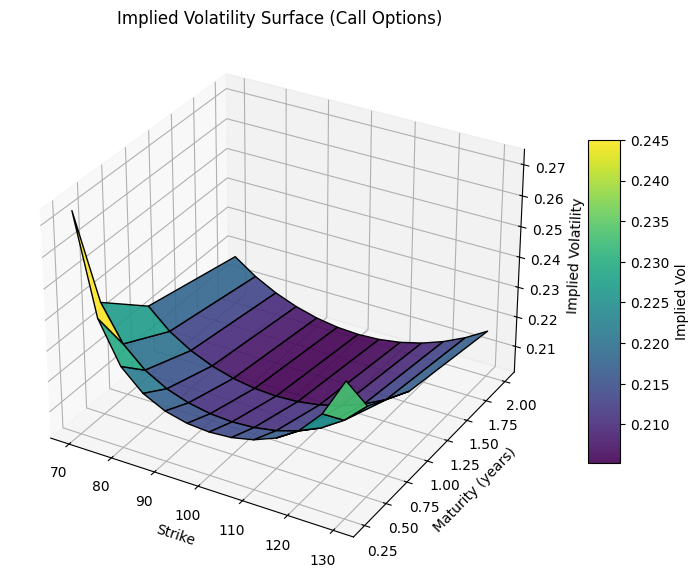

In [6]:
# Create meshgrid for plotting
K_grid, T_grid = np.meshgrid(strikes, maturities)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(K_grid, T_grid, implied_vols, cmap="viridis", edgecolor="k", alpha=0.9)

ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Implied Volatility Surface (Call Options)")

fig.colorbar(surf, shrink=0.6, aspect=10, label="Implied Vol")
plt.show()